In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv
from torch_geometric.utils import to_dense_adj
from torch_geometric.datasets import PPI
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [52]:
from torch_geometric.datasets import PPI

path = './data/PPI'

train_dataset = PPI(root=path, split='train')
val_dataset = PPI(root=path, split='val')
test_dataset = PPI(root=path, split='test')

print(f"Number of training graphs: {len(train_dataset)}")
print(f"Number of validation graphs: {len(val_dataset)}")
print(f"Number of test graphs: {len(test_dataset)}")
print(f"Number of node features: {train_dataset.num_features}")
print(f"Number of classes (labels per node): {train_dataset.num_classes}")

Number of training graphs: 20
Number of validation graphs: 2
Number of test graphs: 2
Number of node features: 50
Number of classes (labels per node): 121


In [53]:
from torch_geometric.utils import to_dense_adj 

train_dataset = PPI(root=path, split='train')
val_dataset = PPI(root=path, split='val')
test_dataset = PPI(root=path, split='test')

In [80]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Dense_GCN(nn.Module):
    def __init__(self, train_data, hidden_dim=256):
        super().__init__()
        
        self.train_adj_params = nn.ParameterList()
        for data in train_data:
            adj_inicial = to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0].clone().float()
            self.train_adj_params.append(nn.Parameter(adj_inicial))
            
        self.gcn1 = DenseGCNConv(train_data.num_features, hidden_dim) 
        self.gcn2 = DenseGCNConv(hidden_dim, hidden_dim)
        self.gcn3 = DenseGCNConv(hidden_dim, train_dataset.num_classes)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)

    def forward(self, x, adj_matrix):
        adj_positive = F.relu(adj_matrix)
        
        adj_norm = self.normalize_adj(adj_positive.unsqueeze(0))
        
        x = self.gcn1(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.gcn2(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.gcn3(x, adj_norm, add_loop=False)
        
        return x
model = Dense_GCN(train_data=train_dataset)
print(model)

Dense_GCN(
  (train_adj_params): ParameterList(
      (0): Parameter containing: [torch.float32 of size 1767x1767]
      (1): Parameter containing: [torch.float32 of size 1377x1377]
      (2): Parameter containing: [torch.float32 of size 2263x2263]
      (3): Parameter containing: [torch.float32 of size 2339x2339]
      (4): Parameter containing: [torch.float32 of size 1578x1578]
      (5): Parameter containing: [torch.float32 of size 1021x1021]
      (6): Parameter containing: [torch.float32 of size 1823x1823]
      (7): Parameter containing: [torch.float32 of size 2488x2488]
      (8): Parameter containing: [torch.float32 of size 591x591]
      (9): Parameter containing: [torch.float32 of size 3312x3312]
      (10): Parameter containing: [torch.float32 of size 2401x2401]
      (11): Parameter containing: [torch.float32 of size 1878x1878]
      (12): Parameter containing: [torch.float32 of size 1819x1819]
      (13): Parameter containing: [torch.float32 of size 3480x3480]
      (14): 

In [81]:
from sklearn.metrics import f1_score

def train(model, dataset, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for graph_id, data in enumerate(dataset):
        data = data.to('cuda')
        x_dense = data.x.unsqueeze(0)
        
        optimizer.zero_grad()
        
        adj_treinavel = model.train_adj_params[graph_id]
        
        out = model(x_dense, adj_treinavel)
        
        loss = criterion(out[0], data.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(dataset)

@torch.no_grad()
def evaluate(model, dataset, criterion):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []
    
    for data in dataset:
        data = data.to('cuda')
        x_dense = data.x.unsqueeze(0).to('cuda')
        
        adj_original = to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0].float().to('cuda')
        
        out = model(x_dense, adj_original)
        
        loss = criterion(out[0], data.y)
        total_loss += loss.item()
        
        probs = torch.sigmoid(out[0])
        preds = (probs > 0.5).float()
        
        y_true.append(data.y.cpu())
        y_pred.append(preds.cpu())
        
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    
    f1 = f1_score(y_true, y_pred, average='micro')
    return total_loss / len(dataset), f1

In [ ]:
import copy
model_gcn = Dense_GCN(train_data=train_dataset)
model_gcn.to("cuda")

print(model_gcn.train_adj_params[0])

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.001)

train_losses = []
val_losses = []
val_f1 = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

for epoch in range(400):
    loss = train(model_gcn,train_dataset, optimizer, criterion)
    
    val_los,val_score_f1 = evaluate(model_gcn,val_dataset,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los) 
    val_f1.append(val_score_f1)
    
    if val_score_f1 > best_val_acc:
        best_val_loss = val_los
        best_val_acc = val_score_f1
        best_epoch = epoch
        best_weights = copy.deepcopy(model_gcn.state_dict())
            
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | ValF1: {val_score_f1:.2f}')
    

Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0', requires_grad=True)
Epoch   0 | Loss: 0.66 | ValLoss: 0.61 | ValF1: 0.41
Epoch  10 | Loss: 0.56 | ValLoss: 0.55 | ValF1: 0.44
Epoch  20 | Loss: 0.54 | ValLoss: 0.53 | ValF1: 0.48
Epoch  30 | Loss: 0.52 | ValLoss: 0.52 | ValF1: 0.49
Epoch  40 | Loss: 0.51 | ValLoss: 0.51 | ValF1: 0.50
Epoch  50 | Loss: 0.50 | ValLoss: 0.50 | ValF1: 0.50
Epoch  60 | Loss: 0.49 | ValLoss: 0.49 | ValF1: 0.51
Epoch  70 | Loss: 0.49 | ValLoss: 0.49 | ValF1: 0.53
Epoch  80 | Loss: 0.48 | ValLoss: 0.49 | ValF1: 0.51
Epoch  90 | Loss: 0.48 | ValLoss: 0.48 | ValF1: 0.51
Epoch 100 | Loss: 0.47 | ValLoss: 0.48 | ValF1: 0.53
Epoch 110 | Loss: 0.47 | ValLoss: 0.48 | ValF1: 0.51
Epoch 120 | Loss: 0.46 | ValLoss: 0.47 | ValF1: 0.5

In [96]:
print(f'Best validation accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}')
if best_weights is not None:
    model_gcn.load_state_dict(best_weights)

print(model_gcn.train_adj_params[0])

Best validation accuracy: 60.14% at epoch 294
Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0', requires_grad=True)


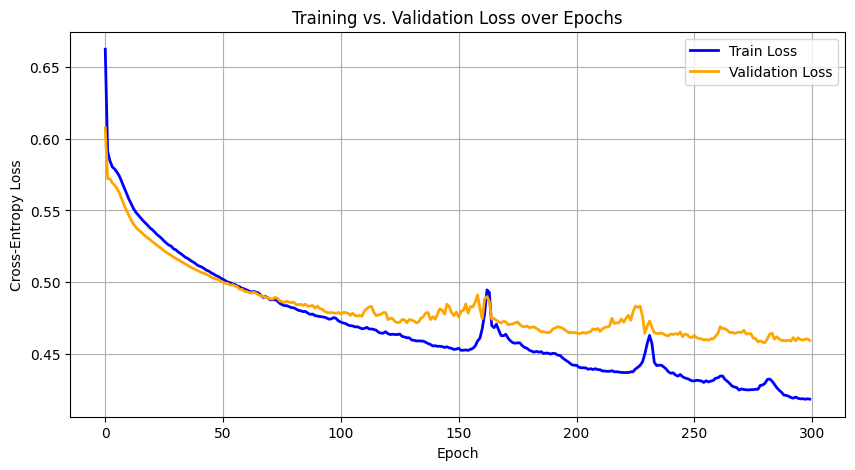

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [98]:
test_loss, test_f1 = evaluate(model_gcn, test_dataset, criterion)
print(f'Test f1: {test_f1:.4f}')

Test f1: 0.6146


## GAT CONV ##

In [81]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(train_dataset.num_features, 128, heads=4) 
        self.gat2 = GATConv(128*4, 128, heads=4)
        self.gat3 = GATConv(128*4, train_dataset.num_classes, heads=6,concat = False)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = self.gat3(x, edge_index)
        return x

model = GAT()
print(model)


GAT(
  (gat1): GATConv(50, 128, heads=4)
  (gat2): GATConv(512, 128, heads=4)
  (gat3): GATConv(512, 121, heads=6)
)


In [ ]:
import copy

model_gat = GAT()
model_gat.to(device = "cuda")

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gat.parameters(),lr=0.005)

train_losses = []
val_losses = []
val_f1

best_val_f1 = 0.0
best_weights = None
best_epoch = 0

for epoch in range(200):
    loss = train(model_gat, optimizer, criterion)
    
    val_los, val_f1_score = evaluate(model_gat,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    val_f1.append(val_f1_score)
    
    if val_f1_score > best_val_f1:
        best_val_f1 = val_f1_score
        best_weights = copy.deepcopy(model_gat.state_dict())
        best_epoch = epoch
       
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | ValF1: {val_f1_score:.2f}')

model_gat.load_state_dict(best_weights)
print(f'Best validation accuracy: {best_val_f1:.4f} at epoch {best_epoch}')


Epoch   0 | Loss: 0.58 | ValLoss: 0.54 | ValF1: 0.42
Epoch  10 | Loss: 0.46 | ValLoss: 0.45 | ValF1: 0.58
Epoch  20 | Loss: 0.41 | ValLoss: 0.42 | ValF1: 0.62
Epoch  30 | Loss: 0.33 | ValLoss: 0.36 | ValF1: 0.72
Epoch  40 | Loss: 0.28 | ValLoss: 0.34 | ValF1: 0.71
Epoch  50 | Loss: 0.24 | ValLoss: 0.29 | ValF1: 0.78
Epoch  60 | Loss: 0.23 | ValLoss: 0.28 | ValF1: 0.79
Epoch  70 | Loss: 0.20 | ValLoss: 0.26 | ValF1: 0.82
Epoch  80 | Loss: 0.17 | ValLoss: 0.28 | ValF1: 0.82
Epoch  90 | Loss: 0.15 | ValLoss: 0.24 | ValF1: 0.84
Epoch 100 | Loss: 0.16 | ValLoss: 0.24 | ValF1: 0.84
Epoch 110 | Loss: 0.14 | ValLoss: 0.27 | ValF1: 0.81
Epoch 120 | Loss: 0.17 | ValLoss: 0.25 | ValF1: 0.84
Epoch 130 | Loss: 0.12 | ValLoss: 0.23 | ValF1: 0.86
Epoch 140 | Loss: 0.13 | ValLoss: 0.23 | ValF1: 0.86
Epoch 150 | Loss: 0.10 | ValLoss: 0.20 | ValF1: 0.88
Epoch 160 | Loss: 0.10 | ValLoss: 0.21 | ValF1: 0.88
Epoch 170 | Loss: 0.10 | ValLoss: 0.22 | ValF1: 0.87
Epoch 180 | Loss: 0.10 | ValLoss: 0.21 | ValF1

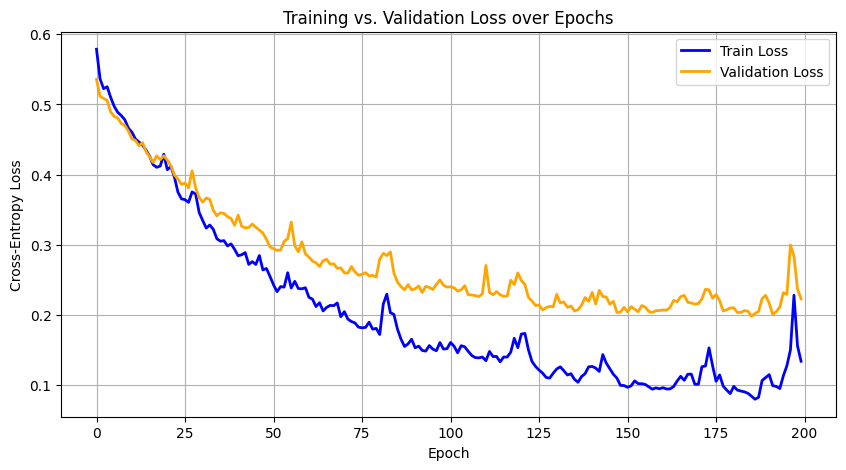

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [87]:
test_f1 = test(model_gat)
print(f'Test Accuracy: {test_f1:.4f}')

Test Accuracy: 0.9188


In [80]:
import torch
import gc

# Deleta o modelo antigo da memória do Python (substitua o nome se for diferente)
if 'model_gat' in globals():
    del model_gat

# Força o coletor de lixo do Python
gc.collect()

# Limpa o cache da placa de vídeo
torch.cuda.empty_cache()

print("Memória da GPU liberada!")

Memória da GPU liberada!
